To check the purity we use

-Entropy

-Gini Index

Information gain is used in selecting the feature for splitting

Entropy = 1 Impure split

= 0 Pure split

Gini impurity = 0.5 (Impure split)

Small dataset - Entropy

Large dataset - Gini Index

Pruning

-Post : After construction of the whole tree 

-Pre : While constructing the tree we'll prune (max step hyper parameter)

## Decision Tree Classifier

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.datasets import load_iris

data=load_iris()
df=pd.DataFrame(data.data, columns=data.feature_names)
df.head()



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


<Axes: >

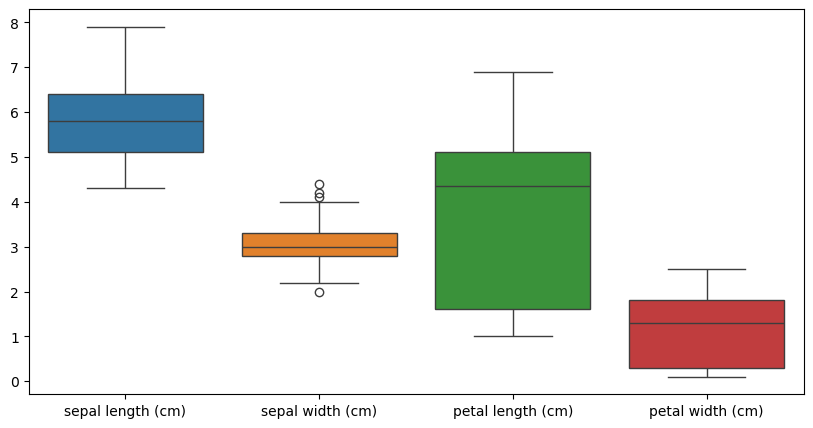

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)

In [12]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

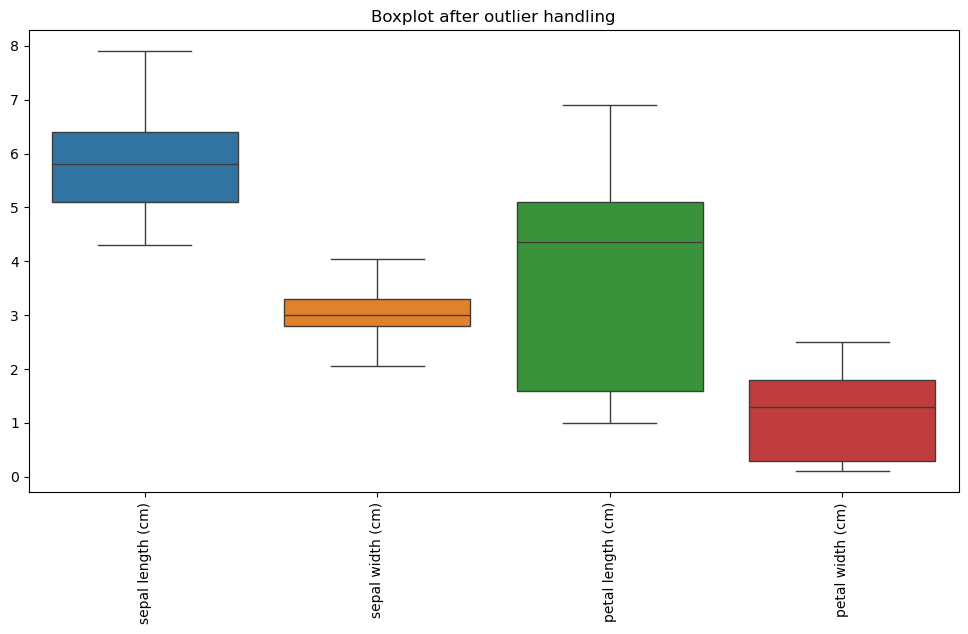

In [13]:
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower, upper)

# verify outliers are handled
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=90)
plt.title("Boxplot after outlier handling")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X=data.data
y=data.target

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [16]:
## apply decision tree classifier
from sklearn.tree import DecisionTreeClassifier
treeclassifier= DecisionTreeClassifier()
treeclassifier= DecisionTreeClassifier(random_state=42)

In [17]:
treeclassifier.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


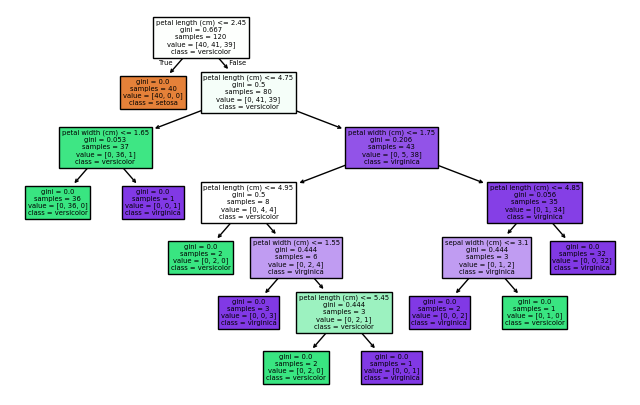

In [28]:
## Visualization of Decision Tree
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

tree.plot_tree(
    treeclassifier,
    filled=True,
    feature_names=data.feature_names,
    class_names=data.target_names
)

plt.show()

In [29]:
from sklearn.tree import DecisionTreeClassifier
tree_classifier=DecisionTreeClassifier(max_depth=3)

In [32]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Load data
data = load_iris()

X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
tree_classifier = DecisionTreeClassifier()

# Train model
tree_classifier.fit(X_train, y_train)

# Predict
y_pred = tree_classifier.predict(X_test)

print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [33]:
Y_pred=tree_classifier.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

a=accuracy_score(y_test,y_pred)
print("Accuracy:",a)
print("Classification Report:\n",classification_report(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [38]:
prams={
    'criterion':['gini','entropy','log_loss'],
    'max_depth':[1,2,3,4,5,6],
    'splitter':['best','random'],
    'max_features':['auto','sqrt','log2']
}

In [39]:
prams

{'criterion': ['gini', 'entropy', 'log_loss'],
 'max_depth': [1, 2, 3, 4, 5, 6],
 'splitter': ['best', 'random'],
 'max_features': ['auto', 'sqrt', 'log2']}

In [40]:
from sklearn.model_selection import GridSearchCV

In [41]:
treemodel=DecisionTreeClassifier()

In [42]:
grid=GridSearchCV(tree_classifier,param_grid=prams,cv=5)

In [45]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [46]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'log2',
 'splitter': 'best'}

In [47]:
grid.best_score_

np.float64(0.9583333333333334)

In [49]:
y_pred=grid.predict(X_test)

In [50]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [53]:
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [55]:
score=accuracy_score(y_test,y_pred)
score

1.0